In [1]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA

from pandas import read_csv, DataFrame, concat

from numpy import arange, full, nan, size, shape, pi

from seaborn import heatmap

from os import path

from qiskit.circuit.library import z_feature_map, unitary_overlap, zz_feature_map

from qiskit.primitives import StatevectorSampler


DATA_PATH = path.join('..', 'data', "water_potability.csv")
RANDOM_SEED = 42
NUMBER_MUESTRAS_ENTRENAMIENTO = 64
USAR_MATRICES_PRECOMPUTADAS = True

# Get data

In [2]:
data = read_csv(DATA_PATH)

data = data.dropna() # hay que limpiar los NaN, si no el normalizar no tiene sentido

data = data.sample(frac=1,\
                   random_state=RANDOM_SEED)

potable_data = data.loc[data['Potability']==1]

unpotable_data = data.loc[data['Potability']==0]

muestras = int((NUMBER_MUESTRAS_ENTRENAMIENTO/.8)/2)

data = concat([potable_data.iloc[0:muestras], \
               unpotable_data.iloc[0:muestras]])


data = data.sample(frac = 1, \
                   random_state=RANDOM_SEED)

'''

Hay que ver si se ponen nuevas features

'''

'''
El documento dice

Imputar valores faltantes (pH: 491 NaN; Sulfato: 781 NaN; Trihalometanos: 162 NaN) por mediana por clase.

Pero no sé si hay que hacer caso a eso xd

'''
potability = data["Potability"]

data = data.drop("Potability", axis = 1) # quitar potabilidad

# Pre-proccess data

In [3]:
data_train, data_test, potability_train, potability_test = \
train_test_split(data, potability, test_size=.2, random_state=RANDOM_SEED)



#scaler = MinMaxScaler(feature_range=(0, 2 * pi))

scaler = StandardScaler()

data_train_scaled = scaler.fit_transform(data_train)
data_test_scaled = scaler.transform(data_test)

pca = PCA(n_components = 4, random_state=RANDOM_SEED)

data_train_scaled = pca.fit_transform(data_train_scaled)

data_test_scaled = pca.transform(data_test_scaled)

# SVM

In [4]:
scores = ["precision", "recall"]

'''
Por si quiero quemar la compu

gamma = ["scale", "auto"]

gamma.extend(list(arange(start = .01, stop = 1, step = .005)))

C = arange(start=1, stop= 1000, step=100)

'''

C = [1, 10]

gamma = ["scale", "auto", .1]


tuned_parameters = [
    {"kernel": ["rbf"], "gamma": gamma, "C":C}
]

def refit_strategy(cv_results):
	
    cv_results_ = DataFrame(cv_results)

    best_index = cv_results_["mean_test_recall"].idxmax()

    return best_index

grid_search = GridSearchCV(
    SVC(), tuned_parameters, scoring=scores, refit=refit_strategy, cv=5, n_jobs=-1
)

grid_search.fit(data_train_scaled, potability_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': [1, 10], 'gamma': ['scale', 'auto', ...], 'kernel': ['rbf']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['precision', 'recall']"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",<function ref...x7fced8958eb0>
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls

# Test

In [5]:
potability_prediction = grid_search.predict(data_test_scaled)

print(f'Confusion matrix: \n {confusion_matrix(potability_test, potability_prediction)}\n')
print(f'Accuracy = {accuracy_score(potability_test, potability_prediction):.2f}')
print(f'Clasification report: \n {classification_report(potability_test, \
potability_prediction, target_names=['Non-Potable' , 'Potable'])}')

Confusion matrix: 
 [[2 7]
 [2 5]]

Accuracy = 0.44
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.50      0.22      0.31         9
     Potable       0.42      0.71      0.53         7

    accuracy                           0.44        16
   macro avg       0.46      0.47      0.42        16
weighted avg       0.46      0.44      0.40        16



In [6]:
results = DataFrame(grid_search.cv_results_)


results.to_csv("laMambaNegra.csv")

print(f'Best params: {grid_search.best_params_}')

results[
    [
        "param_C",
        "param_gamma",
        "mean_test_precision",
        "mean_test_recall",
    ]
]

Best params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


,param_C,param_gamma,mean_test_precision,mean_test_recall
0,1,scale,0.550794,0.671429
1,1,auto,0.585397,0.671429
2,1,0.1,0.534286,0.642857
3,10,scale,0.632302,0.738095
4,10,auto,0.631746,0.676190
5,10,0.1,0.658571,0.647619


<Axes: >

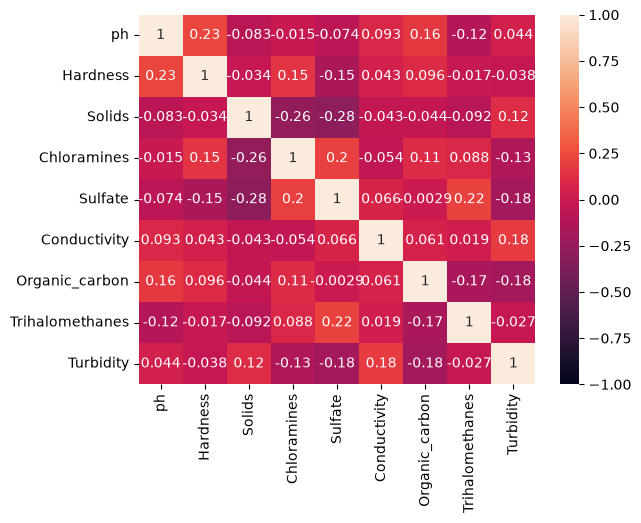

In [7]:
heatmap(data.corr(), \
			 annot=True, \
			 robust=True, \
			 vmin= -1, \
			 vmax= 1)

# QSVM

# Quantum Kernel

In [8]:
fm = z_feature_map(feature_dimension=data_train_scaled.shape[1],\
                  #reps=2
                  )

train_size = data_train_scaled.shape[0]

kernel_matrix = full((train_size, train_size), nan)

'''

Esto es llenar la matriz de kernel con las mediciones del producto interno para ver qué tanto comparten 2 datos

Se tiene una diagonal de 1's puesto que el producto interno consigo mismo es 1

Esta forma ese más efectiva que hacer el cálculo completo, por el gran tamaño de la matriz

'''


sampler = StatevectorSampler(seed=RANDOM_SEED)
num_shots = 100

for x1 in range(0, train_size):
    for x2 in range(x1 + 1, train_size):
        unitary1 = fm.assign_parameters(data_train_scaled[x1])
        unitary2 = fm.assign_parameters(data_train_scaled[x2])

        # Create the overlap circuit
        overlap_circ = unitary_overlap(unitary1, unitary2)
        overlap_circ.measure_all()

        # These lines run the qiskit sampler primitive.
        counts = (
            sampler.run([overlap_circ], shots=num_shots)
            .result()[0]
            .data.meas.get_int_counts()
        )

        # Assign the probability of the 0 state to the kernel matrix, and the transposed element
        # (since this is an inner product)
        kernel_matrix[x1, x2] = counts.get(0, 0.0) / num_shots
        kernel_matrix[x2, x1] = counts.get(0, 0.0) / num_shots
    # Fill in on-diagonal elements with 1, again, since this is an inner-product corresponding to
    # probability (or alter the code to check these entries and verify they yield 1)
    kernel_matrix[x1, x1] = 1
    

# Quantum data Matrix 

In [9]:
test_size = shape(data_test_scaled)[0]

'''
La matriz de prueba tiene forma test x train, ya que me da la relación entre los datos nuevos y los datos utilizados para el entrenamiento
'''

test_matrix = full((test_size, train_size), nan)

for x1 in range(0, test_size):
    for x2 in range(0, train_size):
        unitary1 = fm.assign_parameters(data_test_scaled[x1])
        unitary2 = fm.assign_parameters(data_train_scaled[x2])

        # Create the overlap circuit
        overlap_circ = unitary_overlap(unitary1, unitary2)
        overlap_circ.measure_all()

        # These lines run the qiskit sampler primitive.
        counts = (
            sampler.run([overlap_circ], shots=num_shots)
            .result()[0]
            .data.meas.get_int_counts()
        )

        # Assign the probability of the 0 state to the kernel matrix, and the transposed element
        # (since this is an inner product)
        test_matrix[x1, x2] = counts.get(0, 0.0) / num_shots
    


# Test QSVM

In [10]:
qsvm = SVC(kernel='precomputed')

qsvm.fit(kernel_matrix, potability_train)

potability_prediction = qsvm.predict(test_matrix)


print(f'Confusion matrix: \n {confusion_matrix(potability_test, potability_prediction)}\n')
print(f'Accuracy = {accuracy_score(potability_test, potability_prediction):.2f}')
print(f'Clasification report: \n {classification_report(potability_test, \
potability_prediction, target_names=['Non-Potable' , 'Potable'])}')


Confusion matrix: 
 [[4 5]
 [1 6]]

Accuracy = 0.62
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.80      0.44      0.57         9
     Potable       0.55      0.86      0.67         7

    accuracy                           0.62        16
   macro avg       0.67      0.65      0.62        16
weighted avg       0.69      0.62      0.61        16



In [11]:
import numpy as np
off_diag = kernel_matrix[~np.eye(kernel_matrix.shape[0], dtype=bool)]
print(f"Media: {off_diag.mean():.4f}, Std: {off_diag.std():.4f}")
print(f"Min: {off_diag.min():.4f}, Max: {off_diag.max():.4f}")
print(potability_prediction)
kernel_matrix

Media: 0.1427, Std: 0.1744
Min: 0.0000, Max: 0.9500
[0 0 1 1 0 1 1 0 1 1 0 1 1 1 1 1]


array([[1.  , 0.23, 0.01, ..., 0.06, 0.35, 0.23],
       [0.23, 1.  , 0.01, ..., 0.04, 0.2 , 0.19],
       [0.01, 0.01, 1.  , ..., 0.01, 0.23, 0.09],
       ...,
       [0.06, 0.04, 0.01, ..., 1.  , 0.03, 0.  ],
       [0.35, 0.2 , 0.23, ..., 0.03, 1.  , 0.41],
       [0.23, 0.19, 0.09, ..., 0.  , 0.41, 1.  ]], shape=(64, 64))

In [12]:
print(potability_prediction)
print(potability_test)

[0 0 1 1 0 1 1 0 1 1 0 1 1 1 1 1]
1825    0
1197    1
1624    1
124     0
1647    0
1604    1
1048    0
2531    0
1937    1
842     0
2705    0
910     0
2387    1
2834    1
1625    1
2149    0
Name: Potability, dtype: int64
